## **STUDENT PERFORMANCE FACTORS ANALYSIS, PREDICTION AND VISUALIZATION**

**Importing the libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

**Loading the data**

In [ ]:
df = pd.read_csv("/content/StudentPerformanceFactors.csv")

In [ ]:
df['Result'] = df['Exam_Score'].apply(lambda x: 'Qualified' if x > 65 else 'Disqualified')

In [ ]:
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Result
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,Qualified
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,Disqualified
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,Qualified
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,Qualified
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,Qualified
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,Medium,Public,Positive,2,No,High School,Near,Female,68,Qualified
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,High,Public,Positive,2,No,High School,Near,Female,69,Qualified
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68,Qualified
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,Medium,Private,Positive,3,No,High School,Far,Female,68,Qualified


In [ ]:
df["Result"].value_counts()

,count
Result,
Qualified,4476
Disqualified,2131


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [ ]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


**As it can be seen that there are missing values in columns of Teacher_Quality, Parental_Education_Level and Distance_From_Home which have to be handled.**

In [ ]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


**Handling missing values**

In [ ]:
# Fill the missing values in Teacher_Quality
df["Teacher_Quality"].fillna("others",inplace=True)

# Fill the missing values in Parental_Educational_Level
df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode(),inplace=True)

# Fill the missing values in Distance_From_Home
df["Distance_from_Home"].fillna(df["Distance_from_Home"].mode(),inplace=True)

In [ ]:
df['Teacher_Quality'].value_counts()

,count
Teacher_Quality,
Medium,3925
High,1947
Low,657
others,78


**Visualization and analysis**

In [ ]:
catcol = df.select_dtypes(include="object").columns

In [ ]:
catcol

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender', 'Result'],
      dtype='object')

In [ ]:
numcol = df.select_dtypes(include=np.number).columns

In [ ]:
numcol

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score'],
      dtype='object')

Distribution of key numerical features

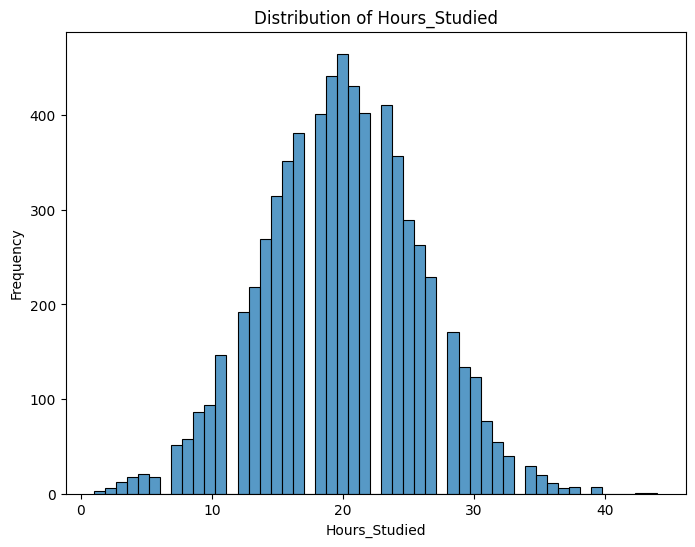

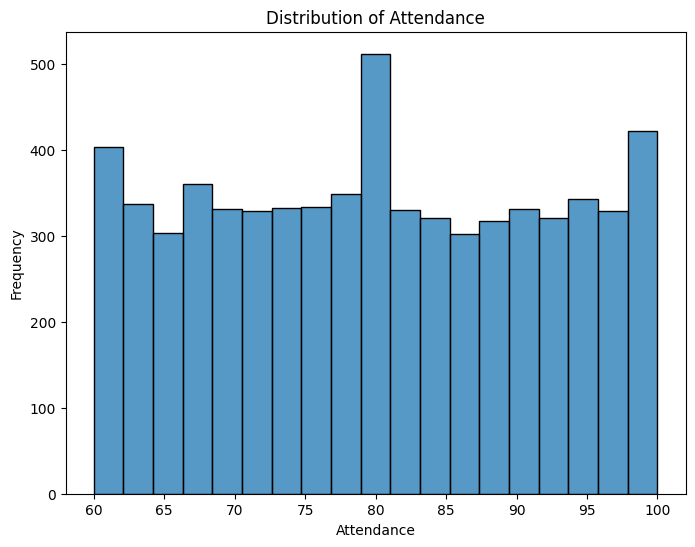

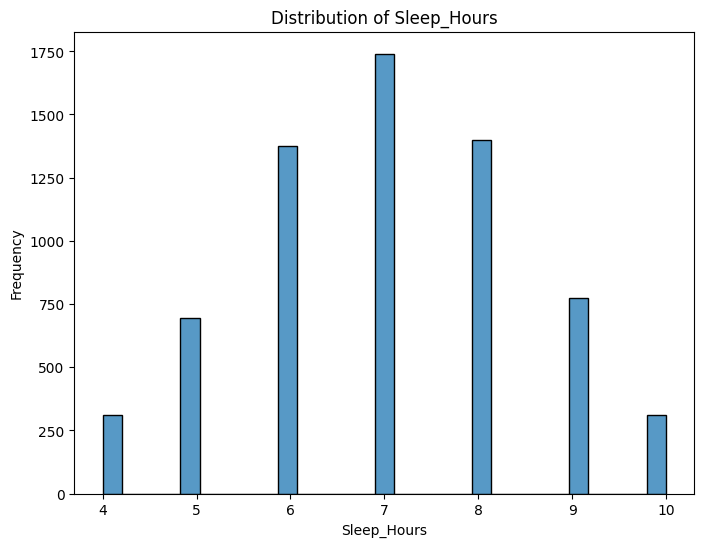

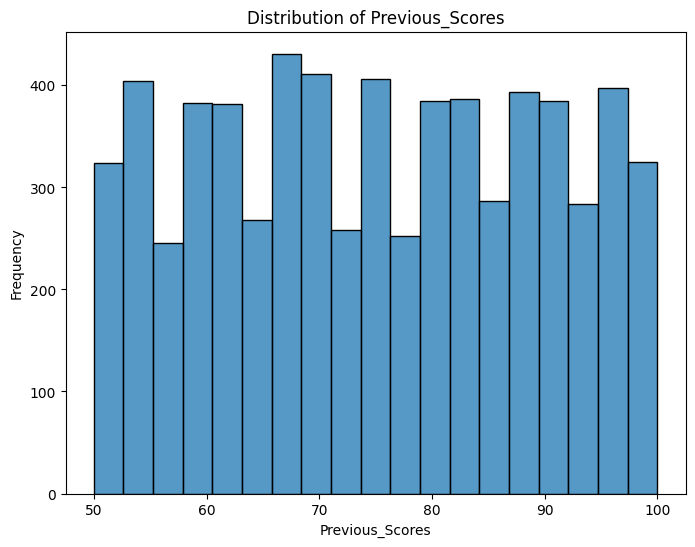

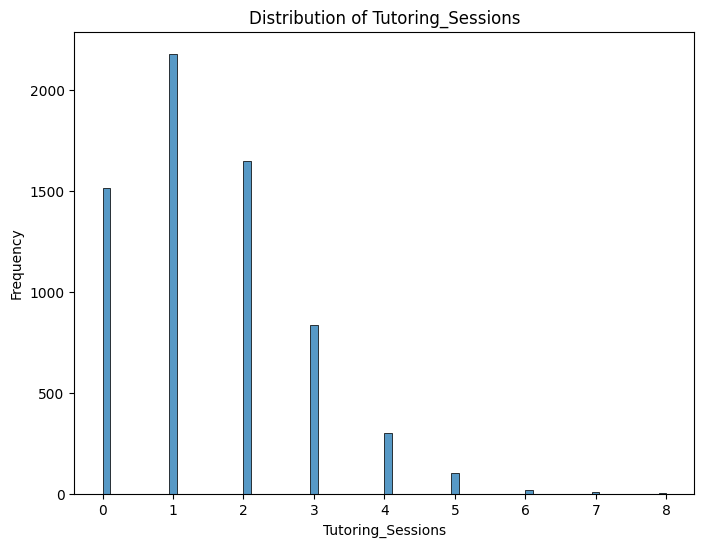

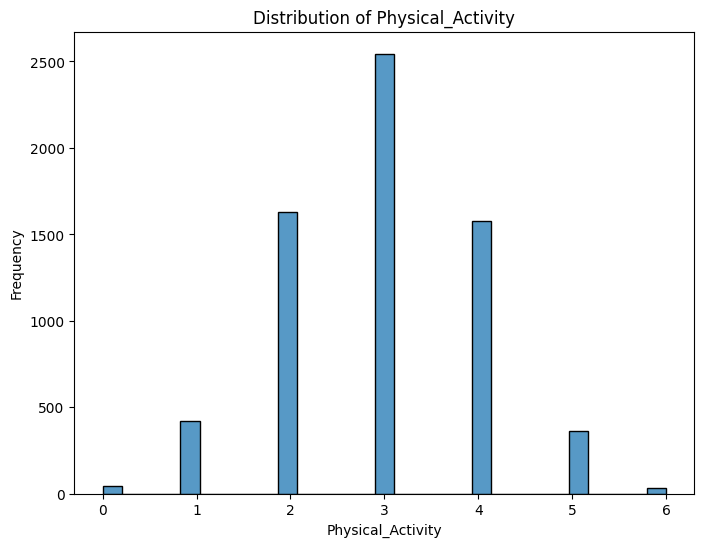

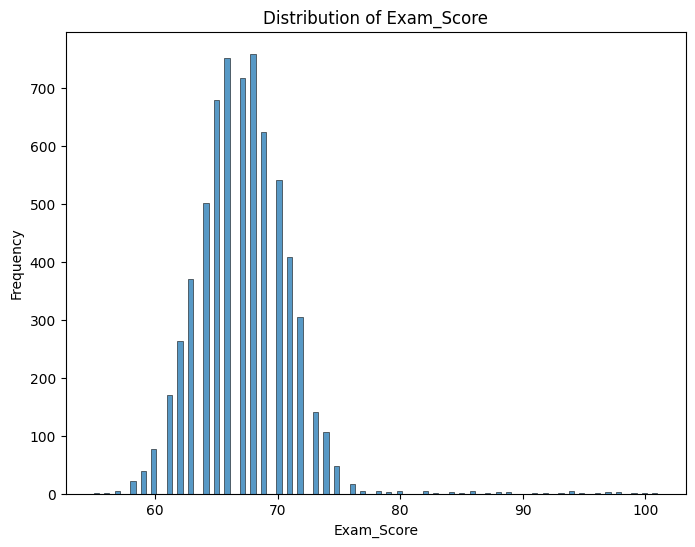

In [ ]:
numcol = df.select_dtypes(include=np.number).columns
for col in numcol:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

Previous_Scores, Teacher_Quality and Result

In [ ]:
mean = df["Previous_Scores"].mean()
mean

np.float64(75.07053125472983)

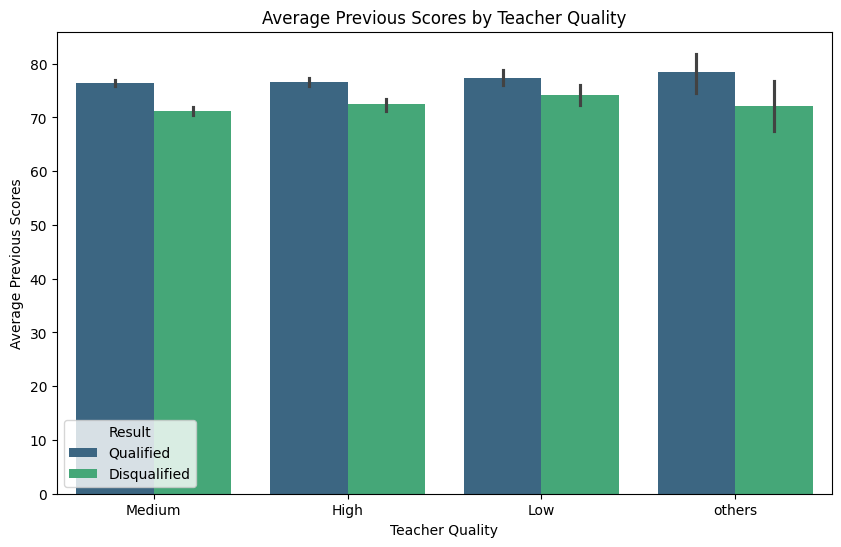

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Teacher_Quality', y='Previous_Scores', hue="Result", data=df, estimator=np.mean, palette='viridis')
plt.title('Average Previous Scores by Teacher Quality')
plt.xlabel('Teacher Quality')
plt.ylabel('Average Previous Scores')
plt.show()

Parental_Involvement, Previous_Scores and Result

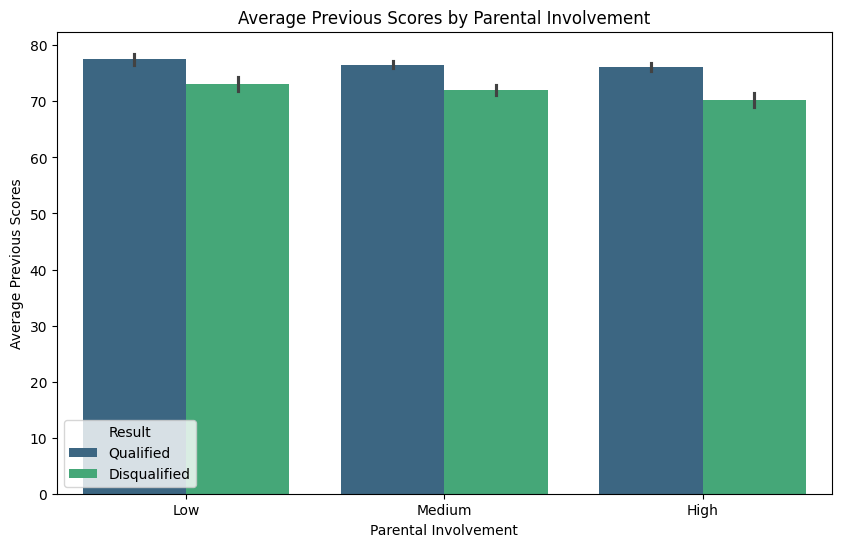

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Parental_Involvement', y='Previous_Scores', hue = "Result", data=df, estimator=np.mean, palette='viridis')
plt.title('Average Previous Scores by Parental Involvement')
plt.xlabel('Parental Involvement')
plt.ylabel('Average Previous Scores')
plt.show()

### Distribution of Gender

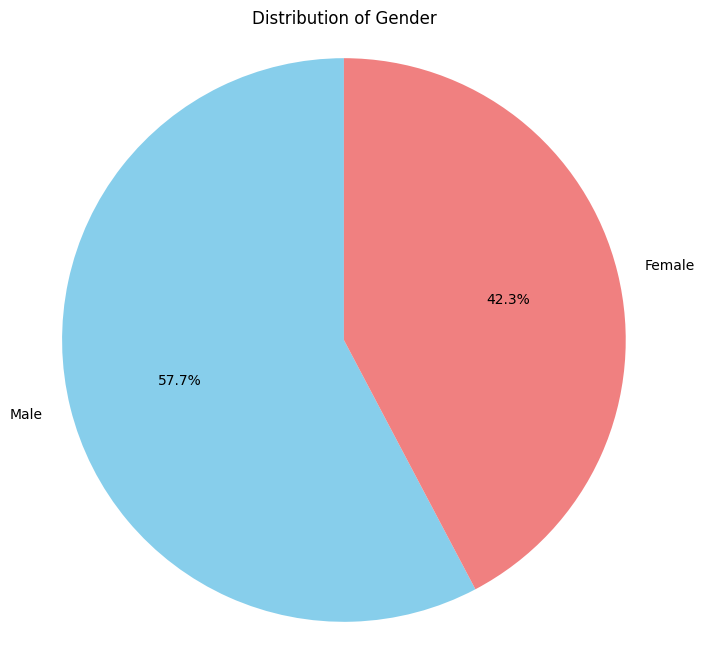

In [ ]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Gender')
plt.axis('equal')
plt.show()

Hours_Studied vs Exam_Score

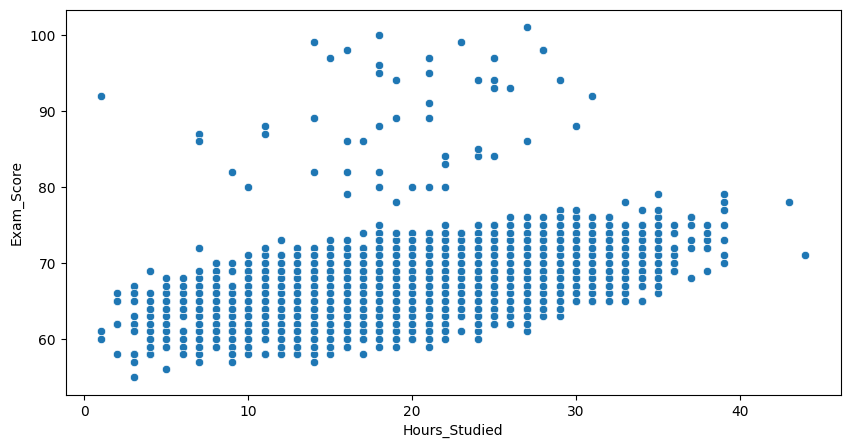

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="Hours_Studied",y="Exam_Score",data=df)
plt.show()

Previous_Scores vs Exam_Scores

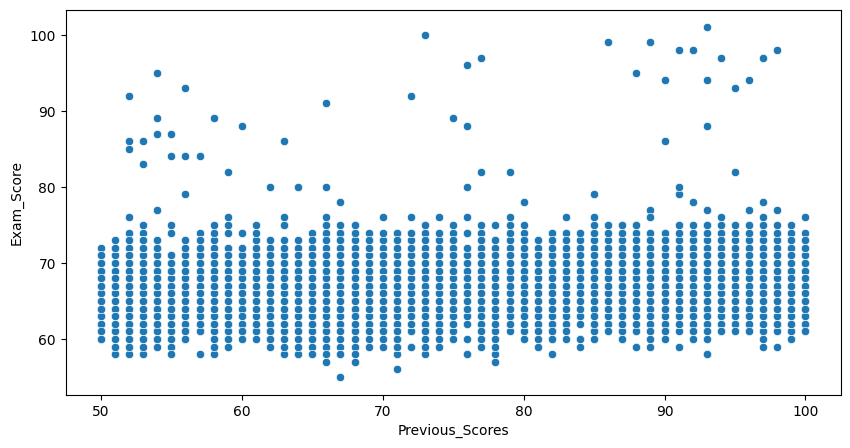

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="Previous_Scores",y="Exam_Score",data=df)
plt.show()

Correlation Heatmap of Numerical Features

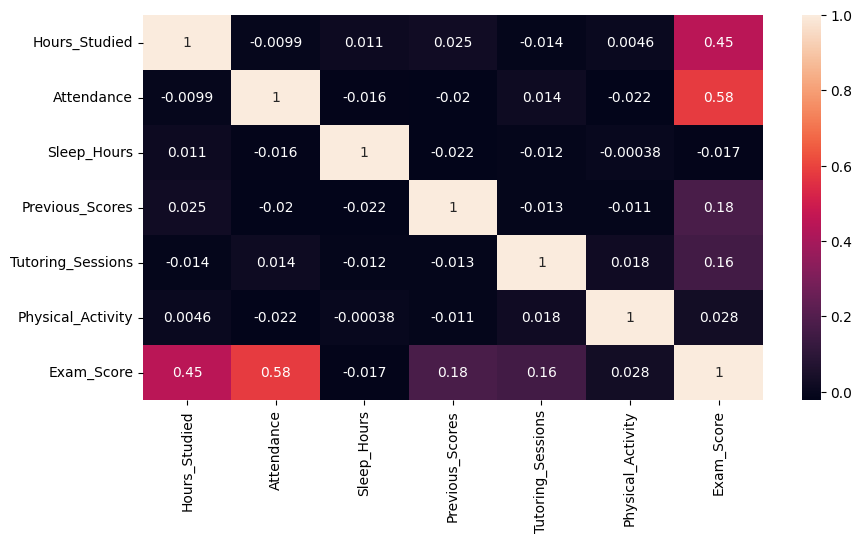

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df[numcol].corr(),annot=True)
plt.show()

**Looking for outliers**

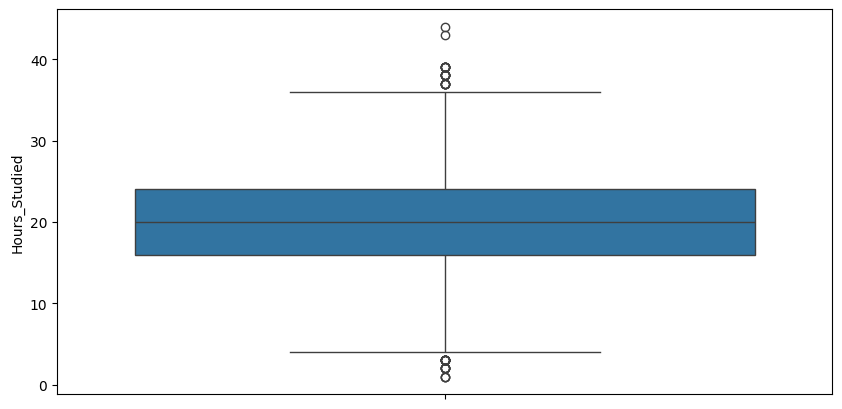

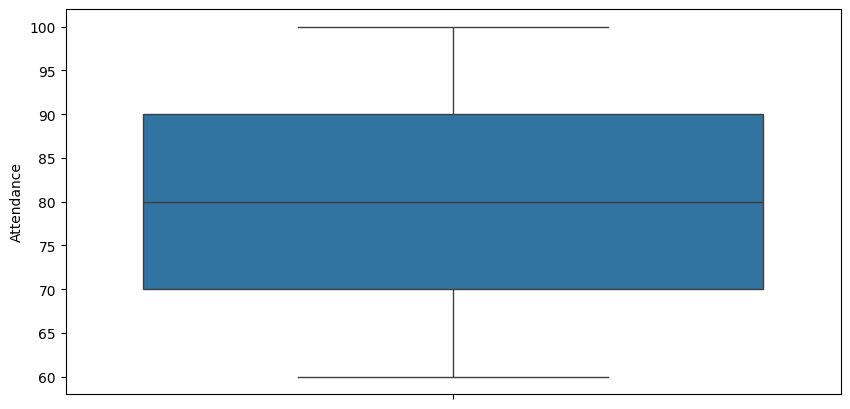

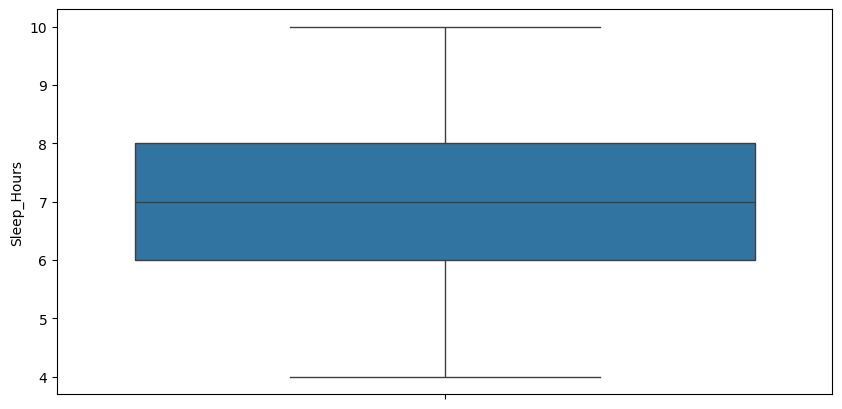

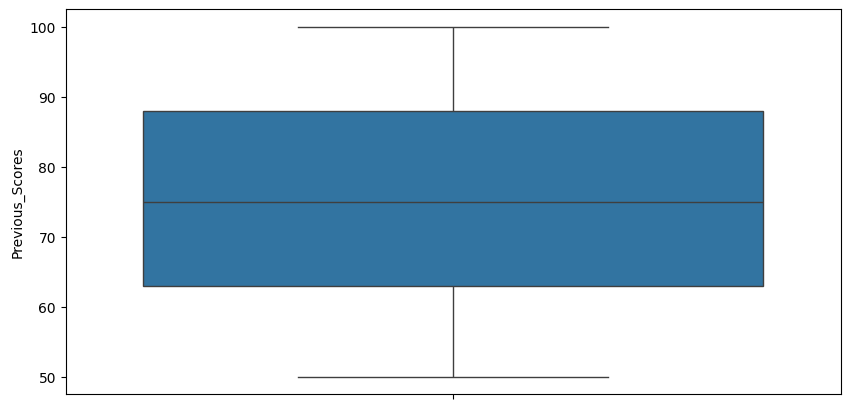

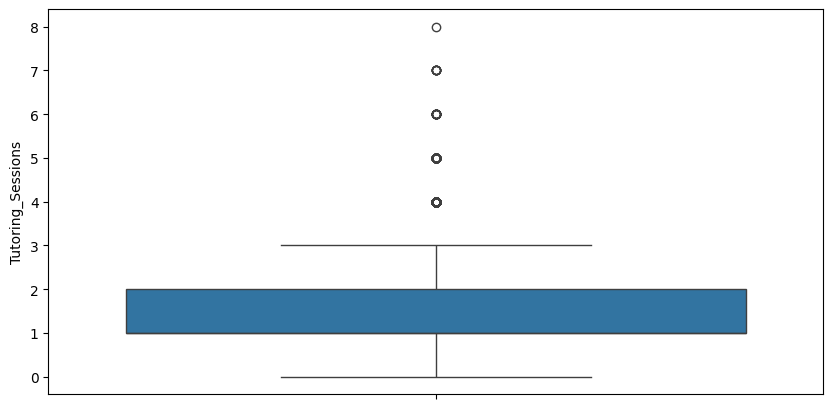

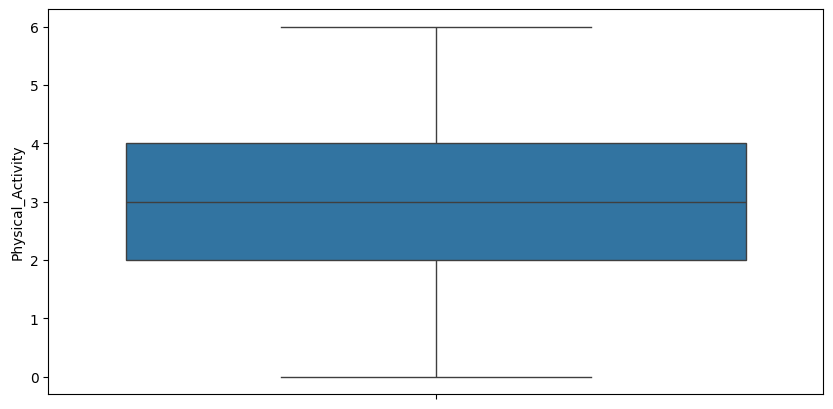

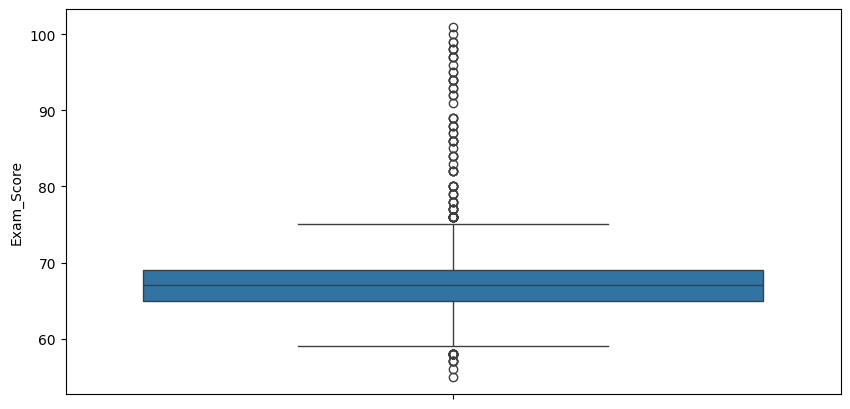

In [ ]:
for i in numcol:
  plt.figure(figsize=(10,5))
  sns.boxplot(df[i])
  plt.show()

Hours_Studies is calculated by hours per week, so even if we divide the 40 which is the highest by 7, the average hours studied per day will still be 5 which is normal in my opinion. Had it been more than 10 hours per day, then I would have considered it as an outlier.
Tutoring_sessions is calculated on the monthly basis which is also normal in my opinion

In [ ]:
for i in catcol:
  print(df[i].value_counts())

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64
Teacher_Quality
Medium    3925
High      1947
Low        657
others      78
Name: count, dtype: int64
School_Type
Public     4598
Private    2009
Name: count, dtype: int64
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64
Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64
Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64
Distance_from_Home
Near        3884
Moderate    199

# **Training the data for the model**

**Encoding the data**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
colname=df.select_dtypes(object).columns
colname

Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender', 'Result'],
      dtype='object')

In [ ]:
for col in colname:
    df[col] = le.fit_transform(df[col])
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Result
0,23,84,1,0,0,7,73,1,1,0,...,2,1,2,3,0,1,2,1,67,1
1,19,64,1,2,0,8,59,1,1,2,...,2,1,0,4,0,0,1,0,61,0
2,24,98,2,2,1,7,91,2,1,2,...,2,1,1,4,0,2,2,1,74,1
3,29,89,1,2,1,8,98,2,1,1,...,2,1,0,4,0,1,1,1,71,1
4,19,92,2,2,1,6,65,2,1,3,...,0,1,1,4,0,0,2,0,70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,0,2,0,7,76,2,1,1,...,2,1,2,2,0,1,2,0,68,1
6603,23,76,0,2,0,8,81,2,1,3,...,0,1,2,2,0,1,2,0,69,1
6604,20,90,2,1,1,6,65,1,1,3,...,2,1,0,2,0,2,2,0,68,1
6605,10,86,0,0,1,6,91,0,1,2,...,2,0,2,3,0,1,0,0,68,1


In [ ]:
 # df.to_excel("output.xlsx", index=False)

**Scaling the data**

In [ ]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

In [ ]:
X= df.drop("Result",axis=1)
print(X.columns)
Y= df["Result"]
Y

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')


,Result
0,1
1,0
2,1
3,1
4,1
...,...
6602,1
6603,1
6604,1
6605,1


In [ ]:
X= ss.fit_transform(X)
X

array([[ 0.50494151,  0.34837541, -0.25424875, ...,  0.71731608,
         0.85574648, -0.06057825],
       [-0.16282241, -1.38373605, -0.25424875, ..., -0.74227965,
        -1.16857039, -1.60293072],
       [ 0.67188249,  1.56085343,  0.90106177, ...,  0.71731608,
         0.85574648,  1.73883298],
       ...,
       [ 0.00411857,  0.86800885,  0.90106177, ...,  0.71731608,
        -1.16857039,  0.1964805 ],
       [-1.66529123,  0.52158655, -1.40955928, ..., -2.20187539,
        -1.16857039,  0.1964805 ],
       [-0.83058633, -1.12391933,  0.90106177, ...,  0.71731608,
         0.85574648, -0.83175448]])

**Splitting the data**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=10)

**KNN**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)
pred=knn.predict(x_test)
pred

array([1, 0, 1, ..., 1, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,pred)

0.8903177004538578

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
#confusion_matrix(y_test,pred)
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.84      0.80      0.82       420
           1       0.91      0.93      0.92       902

    accuracy                           0.89      1322
   macro avg       0.88      0.87      0.87      1322
weighted avg       0.89      0.89      0.89      1322



**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)
predlog=lr.predict(x_test)
predlog

array([1, 1, 1, ..., 1, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test,predlog))
print("Confusion Matrix:\n", confusion_matrix(y_test,predlog))
print("Classification Report:\n", classification_report(y_test,predlog))

Accuracy: 1.0
Confusion Matrix:
 [[420   0]
 [  0 902]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       420
           1       1.00      1.00      1.00       902

    accuracy                           1.00      1322
   macro avg       1.00      1.00      1.00      1322
weighted avg       1.00      1.00      1.00      1322



**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train,y_train)
pred=rf.predict(x_test)
pred

array([1, 1, 1, ..., 1, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,pred)

1.0

**Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
pred=dt.predict(x_test)
pred

array([1, 1, 1, ..., 1, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test,pred))
print("Confusion Matrix:\n", confusion_matrix(y_test,pred))
print("Classification Report:\n", classification_report(y_test,pred))
accuracy_score(y_test,pred)

Accuracy: 1.0
Confusion Matrix:
 [[420   0]
 [  0 902]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       420
           1       1.00      1.00      1.00       902

    accuracy                           1.00      1322
   macro avg       1.00      1.00      1.00      1322
weighted avg       1.00      1.00      1.00      1322



1.0

**Hyperparameter Tuning of KNN**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
for i in range(1,100,2):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(x_train,y_train)
  pred=knn.predict(x_test)
  print(i,accuracy_score(y_test,pred))

1 0.829803328290469
3 0.8721633888048411
5 0.8903177004538578
7 0.8993948562783661
9 0.9009077155824509
11 0.8963691376701967
13 0.9016641452344932
15 0.9016641452344932
17 0.9114977307110439
19 0.9046898638426626
21 0.9084720121028744
23 0.9167927382753404
25 0.9183055975794251
27 0.9198184568835098
29 0.9205748865355522
31 0.9190620272314675
33 0.9152798789712556
35 0.9183055975794251
37 0.9152798789712556
39 0.9114977307110439
41 0.9183055975794251
43 0.9175491679273827
45 0.9145234493192134
47 0.9198184568835098
49 0.9228441754916793
51 0.9236006051437217
53 0.9190620272314675
55 0.9198184568835098
57 0.924357034795764
59 0.9213313161875946
61 0.9258698940998488
63 0.924357034795764
65 0.924357034795764
67 0.9228441754916793
69 0.9220877458396369
71 0.9213313161875946
73 0.9236006051437217
75 0.9213313161875946
77 0.9228441754916793
79 0.9228441754916793
81 0.9228441754916793
83 0.9251134644478064
85 0.926626323751891
87 0.924357034795764
89 0.9236006051437217
91 0.9251134644478064

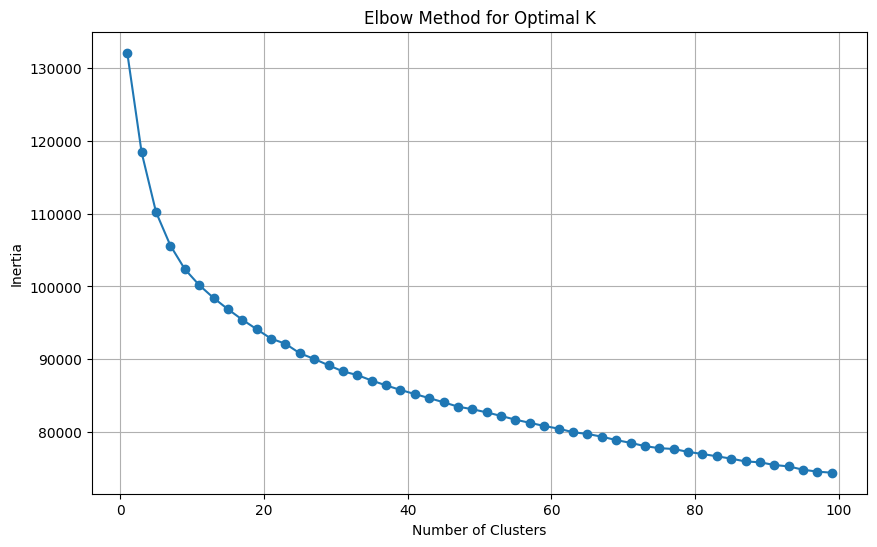

In [ ]:
from sklearn.cluster import KMeans
inertia_values = []
for i in range(1,100,2):
  kmeans = KMeans(n_clusters=i,random_state=42,n_init=10)
  kmeans.fit(X)
  inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(range(1,100,2),inertia_values,marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()

In [ ]:
knn = KNeighborsClassifier(n_jobs=-1)

In [ ]:
param_grid = {
    "n_neighbors": [79,85,99],
    "algorithm": ['auto', 'ball_tree', 'kd_tree', 'brute'],
    "weights": ['uniform', 'distance'],
}

In [ ]:
rsv = RandomizedSearchCV(knn,param_grid,verbose=True,refit=True,n_jobs=-1)

In [ ]:
rsv.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(estimator=KNeighborsClassifier(n_jobs=-1), n_jobs=-1,
                   param_distributions={'algorithm': ['auto', 'ball_tree',
                                                      'kd_tree', 'brute'],
                                        'n_neighbors': [79, 85, 99],
                                        'weights': ['uniform', 'distance']},
                   verbose=True)

In [ ]:
print(rsv.best_params_)

{'weights': 'distance', 'n_neighbors': 79, 'algorithm': 'ball_tree'}


In [ ]:
y_pred = rsv.predict(x_test)

In [ ]:
print("Accuracy Score: ",accuracy_score(y_test,y_pred))

Accuracy Score:  0.9228441754916793


In [ ]:
from sklearn.metrics import confusion_matrix,classification_report

best_knn_model = rsv.best_estimator_

y_pred_best = best_knn_model.predict(x_test)

accuracy_best = accuracy_score(y_test, y_pred_best)
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
class_report_best = classification_report(y_test, y_pred_best)

print("Best KNN Model:")
print("Accuracy:", accuracy_best)
print("Confusion Matrix:\n", conf_matrix_best)
print("Classification Report:\n", class_report_best)

Best KNN Model:
Accuracy: 0.9228441754916793
Confusion Matrix:
 [[329  91]
 [ 11 891]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.78      0.87       420
           1       0.91      0.99      0.95       902

    accuracy                           0.92      1322
   macro avg       0.94      0.89      0.91      1322
weighted avg       0.93      0.92      0.92      1322

